In [16]:
import choix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

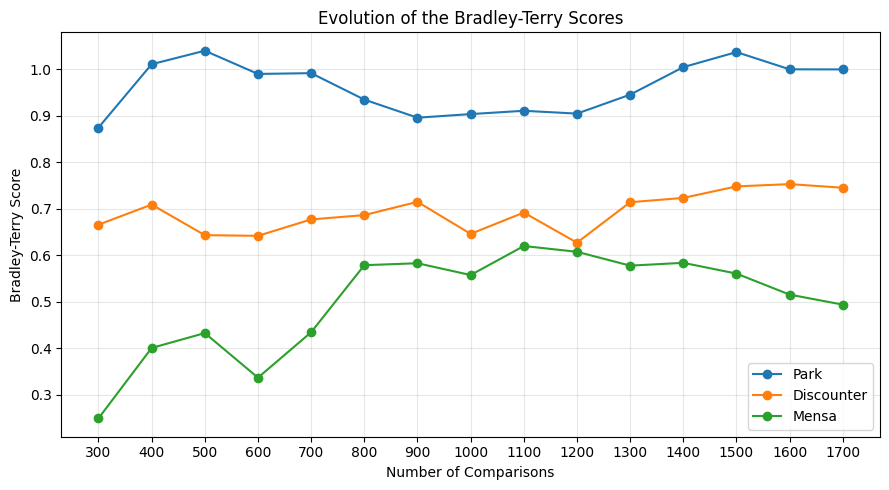

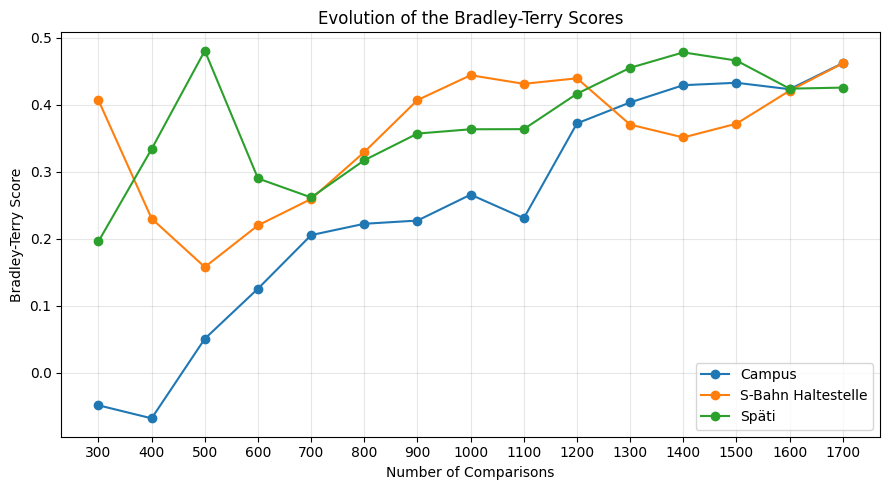

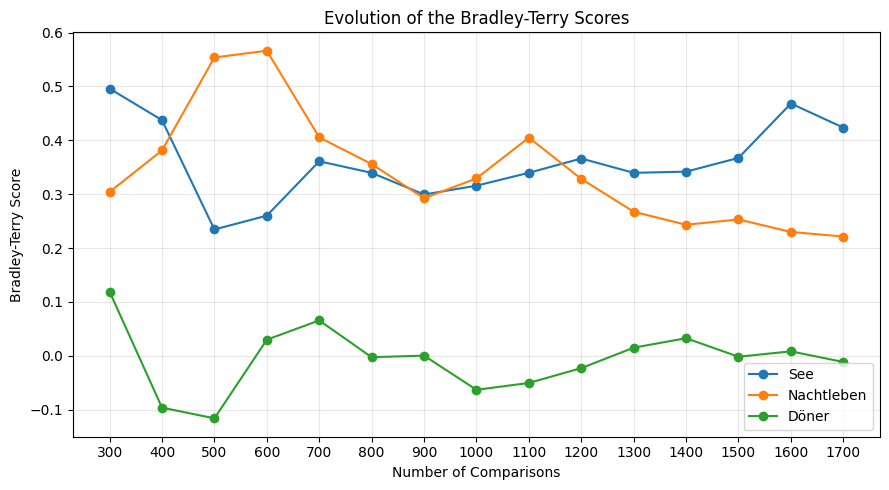

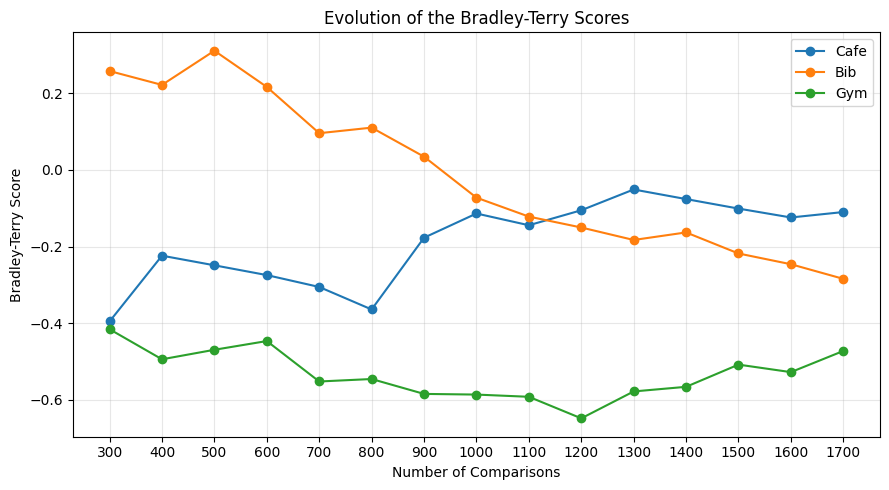

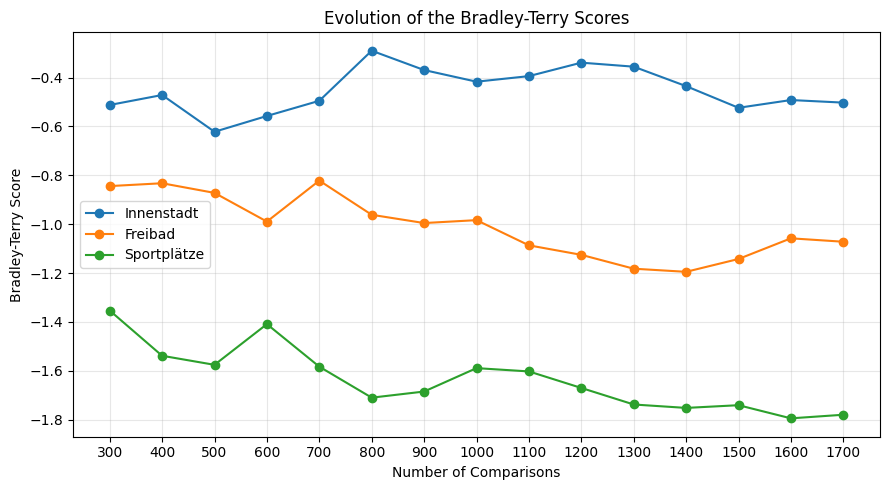

In [ ]:
# Input -> .csv mit den paarweisen Vergleichen
df = pd.read_csv('/Users/aaronzumdick/VSCode/sterni/vergleiche.csv') # Eventuell ersetzen

# Alle möglichen Elemente aus den Vergleichen extrahieren
elemente = pd.unique(df[['winner', 'loser']].values.ravel())

# Mapping für die Elemente auf Id
elementAufId = {item: i for i, item in enumerate(elemente)}

# Die Vergleiche encoden
comparisons = [
    (elementAufId[winner], elementAufId[loser])
    for winner, loser in zip(df['winner'], df['loser'])
]

comparisons = np.array(comparisons)
np.random.shuffle(comparisons)

# Reverse Mapping
idAufElement = {i: item for item, i in elementAufId.items()}

anzahlelemente = len(elemente)

# Checkpoints für Score-Berechnung
checkpoints = [300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700]
scores = []

# Score bzw. Ranking LL berechnen
for n in checkpoints:
    params = choix.ilsr_pairwise(
        anzahlelemente,
        comparisons[:n]
    )

    params = params - params.mean()

    scores.append(params)

# In Dataframe speichern
allscores = pd.DataFrame(
    scores,
    index=checkpoints,
    columns=[idAufElement[i] for i in range(anzahlelemente)]
)

# Anzahl Kategorien pro Plot für Lesbarkeit
plotsize = 3

# Items nach finalem Score sortieren
sorted = allscores.loc[1700].sort_values(ascending=False).index

# Item-Gruppen mit jeweils 3 Items erstellen
itemgroups = [
    sorted[i:i + plotsize]
    for i in range(0, len(sorted), plotsize)
]

# Item-Gruppen plotten
for group in itemgroups:
    plt.figure(figsize=(9, 5))
    

    for item in group:
        plt.plot(
            allscores.index,
            allscores[item],
            marker='o',
            label=item
        )

    plt.xlabel("Number of Comparisons")
    plt.ylabel("Bradley-Terry Score")
    plt.title("Evolution of the Bradley-Terry Scores")
    plt.xticks(allscores.index)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
# Alle Vergleiche -> Siege zählen
wins = np.bincount(
    comparisons[:, 0],
    minlength=anzahlelemente
)

# Niederlagen zählen
losses = np.bincount(
    comparisons[:, 1],
    minlength=anzahlelemente
)

# Gesamtanzahl Vergleiche
total = wins + losses

result = pd.DataFrame({
    "Klasse": [idAufElement[i] for i in range(anzahlelemente)],
    "Siege": wins,
    "Niederlagen": losses,
    "Vergleiche": total,
    "Siegrate": 100 * wins / total
})

result = result.sort_values(
    "Siegrate",
    ascending=False
)

print(result)

# Balkendiagramm yallah

                Klasse  Siege  Niederlagen  Vergleiche   Siegrate
3                 Park    249          103         352  70.738636
5           Discounter    200          112         312  64.102564
8                Mensa    167          115         282  59.219858
2                Späti    154          115         269  57.249071
14              Campus    149          115         264  56.439394
9   S-Bahn Haltestelle    146          114         260  56.153846
6                  See    149          118         267  55.805243
0           Nachtleben    115          118         233  49.356223
11               Döner     96          120         216  44.444444
7                 Cafe     87          114         201  43.283582
10                 Bib     75          116         191  39.267016
12                 Gym     59          119         178  33.146067
13          Innenstadt     59          124         183  32.240437
1              Freibad     35          129         164  21.341463
4         

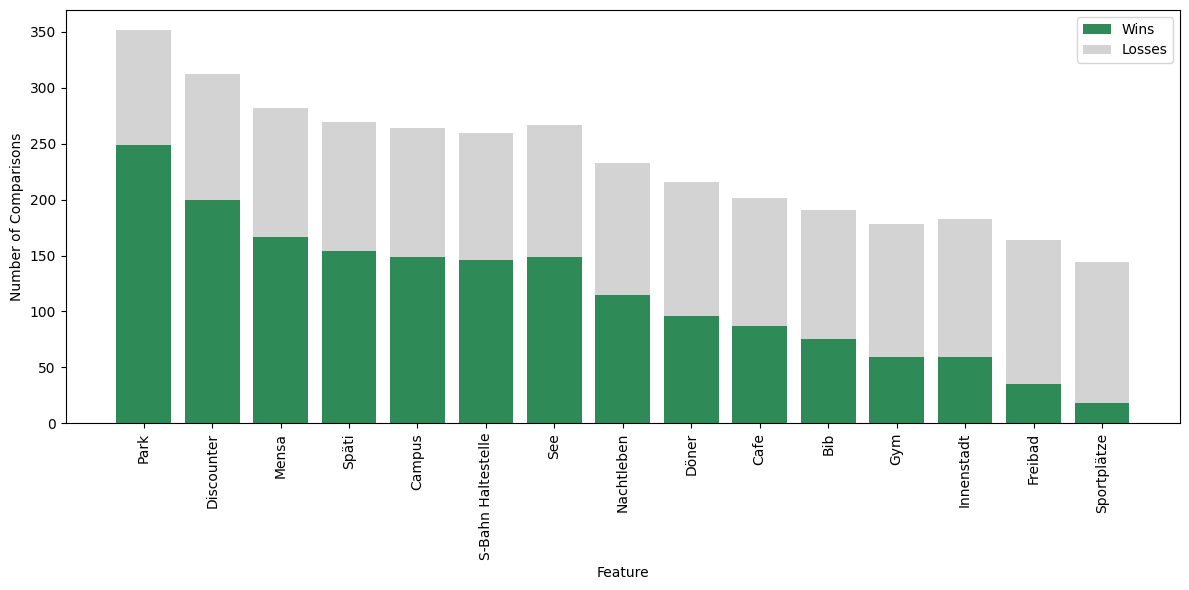

In [19]:
plt.figure(figsize=(12, 6))

plt.bar(
    result["Klasse"],
    result["Siege"],
    color="seagreen",
    label="Wins"
)

plt.bar(
    result["Klasse"],
    result["Niederlagen"],
    bottom=result["Siege"],
    color="lightgrey",
    label="Losses"
)

plt.xlabel("Feature")
plt.ylabel("Number of Comparisons")

plt.xticks(rotation=90)
plt.legend()

plt.tight_layout()
plt.show()